In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:

states = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/state.csv")

states.head(10)

In [4]:
print(states["Murder.Rate"].head(10).mean())
print(states["Murder.Rate"].head(10).median())
print(states["Murder.Rate"].head(10).std())
print(states["Murder.Rate"].head(10).quantile([0.25,0.5,0.75]))

4.85
5.6
1.282575533838066
0.25    4.475
0.50    5.600
0.75    5.700
Name: Murder.Rate, dtype: float64


In [5]:
states.head(10).sort_values(by="Murder.Rate")

,State,Population,Murder.Rate,Abbreviation
6,Connecticut,3574097,2.4,CT
5,Colorado,5029196,2.8,CO
4,California,37253956,4.4,CA
2,Arizona,6392017,4.7,AZ
1,Alaska,710231,5.6,AK
3,Arkansas,2915918,5.6,AR
0,Alabama,4779736,5.7,AL
9,Georgia,9687653,5.7,GA
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL


Text(0, 0.5, 'Population (millions)')

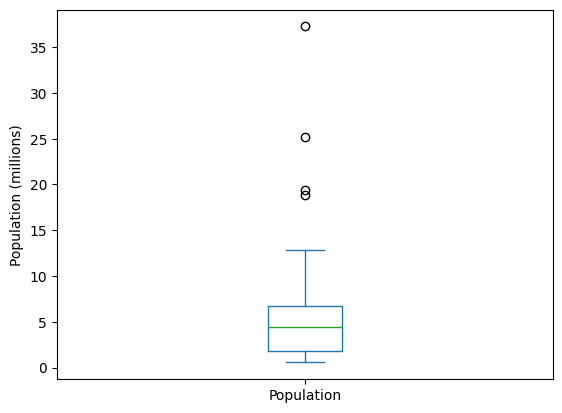

In [6]:
# Box plot
ax = (states["Population"]/1_000_000).plot.box()
ax.set_ylabel("Population (millions)")

In [7]:
states.sort_values(by="Population", ascending=False).head(10)

,State,Population,Murder.Rate,Abbreviation
4,California,37253956,4.4,CA
42,Texas,25145561,4.4,TX
31,New York,19378102,3.1,NY
8,Florida,18801310,5.8,FL
12,Illinois,12830632,5.3,IL
37,Pennsylvania,12702379,4.8,PA
34,Ohio,11536504,4.0,OH
21,Michigan,9883640,5.4,MI
9,Georgia,9687653,5.7,GA
32,North Carolina,9535483,5.1,NC


In [8]:
binned = pd.cut(states["Population"], bins=10)
binned.value_counts()


Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64

Text(0.5, 0, 'Population (millions)')

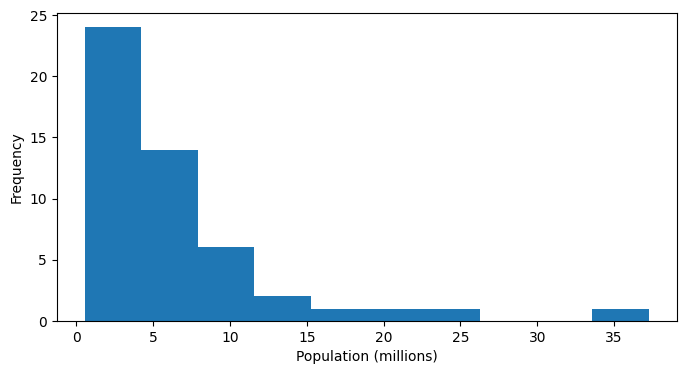

In [9]:
ax = (states['Population'] / 1_000_000).plot.hist(figsize=(8, 4))
ax.set_xlabel('Population (millions)')

Text(0.5, 0, 'murder rate (per 100 000)')

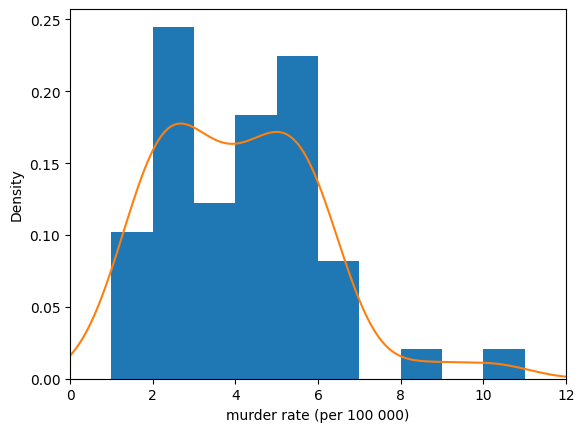

In [10]:
# Density curve
ax = states["Murder.Rate"].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
states["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("murder rate (per 100 000)")

In [11]:
dfw_airline = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/dfw_airline.csv")

dfw_airline

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


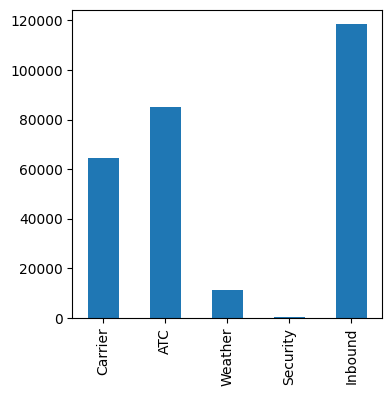

In [12]:
ax = dfw_airline.transpose().plot.bar(figsize=(4,4), legend=False)


In [13]:
sp500_sym = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/sp500_sectors.csv")
sp500_px = pd.read_csv("data/sp500_data.csv.gz", index_col=0)



In [14]:
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
print(telecom)

telecom.corr()


                   T       CTL       FTR        VZ      LVLT
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


In [15]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', 
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

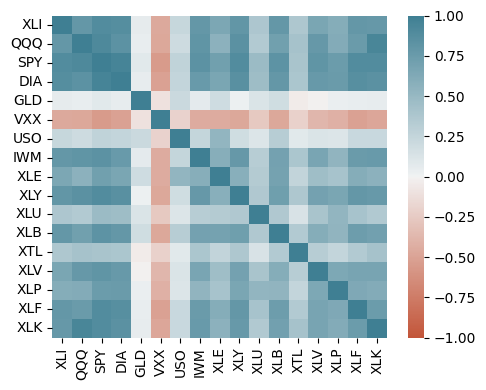

In [16]:

fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1, 
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 ax=ax)

plt.tight_layout()
plt.show()

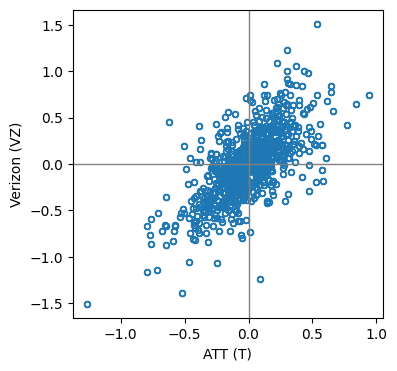

In [17]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

In [31]:
kc_tax = pd.read_csv("data/kc_tax.csv.gz")
kc_tax.head(10)
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000)  & (kc_tax.SqFtTotLiving > 100) & (kc_tax.SqFtTotLiving < 3500), :]

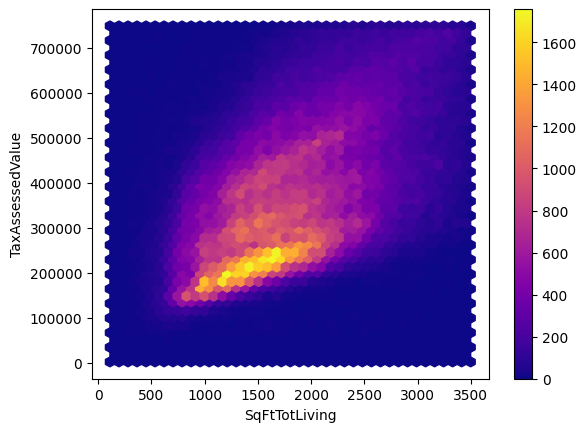

In [19]:
ax = kc_tax0.plot.hexbin(x="SqFtTotLiving", y="TaxAssessedValue",gridsize=40, sharex=True, cmap="plasma")

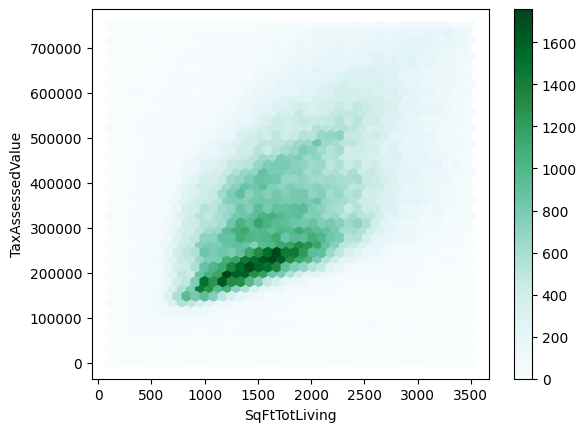

In [20]:
ax = kc_tax0.plot.hexbin(x="SqFtTotLiving", y="TaxAssessedValue",gridsize=40, sharex=False)

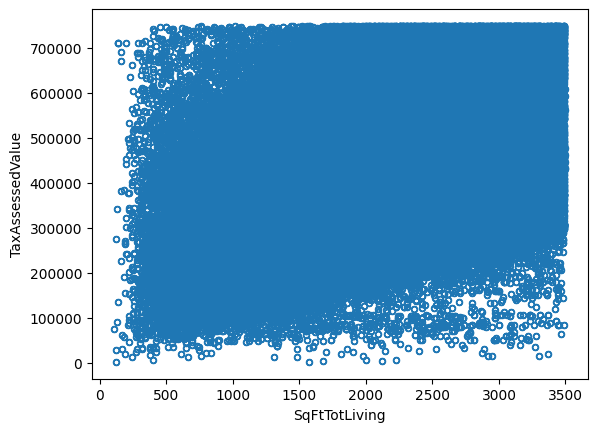

In [21]:
ax = kc_tax0.plot.scatter(x="SqFtTotLiving", y="TaxAssessedValue", marker="$\u25EF$")

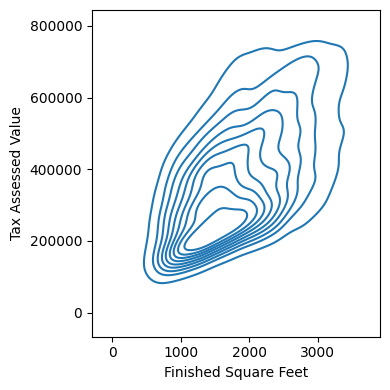

In [22]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

In [4]:
airline_stats = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/airline_stats.csv")
airline_stats

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


Text(0.5, 0.98, '')

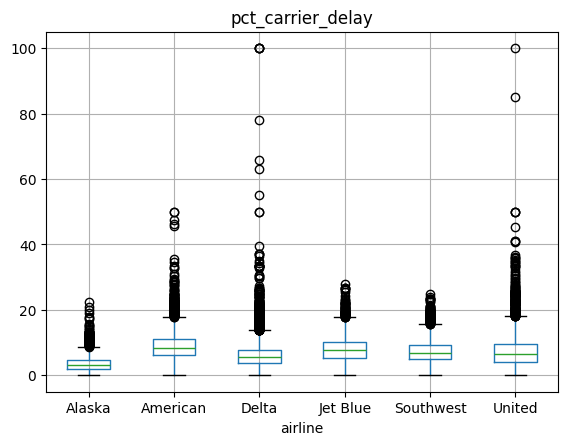

In [8]:
airline_stats.boxplot(by="airline", column="pct_carrier_delay")
plt.suptitle('')

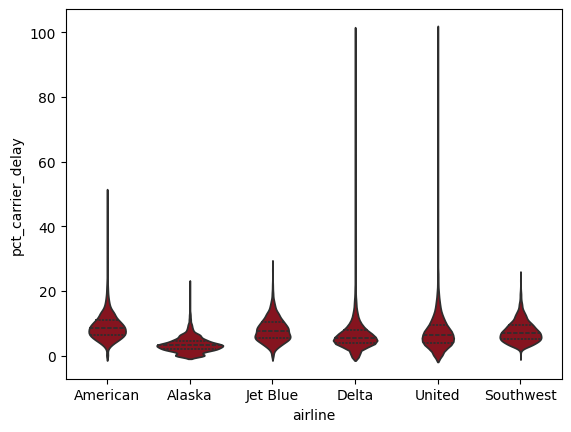

In [29]:
ax = sns.violinplot(x=airline_stats.airline, y=airline_stats.pct_carrier_delay, inner="quartile", color="#980110")

In [32]:
kc_tax0

,TaxAssessedValue,SqFtTotLiving,ZipCode
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
5,223000.0,1570,98032.0
...,...,...,...
498244,375000.0,2230,98056.0
498245,316000.0,1710,98056.0
498246,340000.0,1930,98056.0
498247,132000.0,2930,98056.0


In [35]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]
kc_tax_zip

,TaxAssessedValue,SqFtTotLiving,ZipCode
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
10,202000.0,830,98108.0
11,210000.0,1130,98108.0
12,193000.0,1560,98108.0
...,...,...,...
498049,346000.0,1430,98105.0
498050,463000.0,1610,98105.0
498051,553000.0,1580,98105.0
498052,571000.0,1840,98105.0


C:\Users\user\AppData\Local\Temp\ipykernel_8684\2519678349.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x,y,  cmap=cmap, **kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_8684\2519678349.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x,y,  cmap=cmap, **kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_8684\2519678349.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x,y,  cmap=cmap, **kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_8684\2519678349.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x,y,  cmap=cmap, **kwargs)


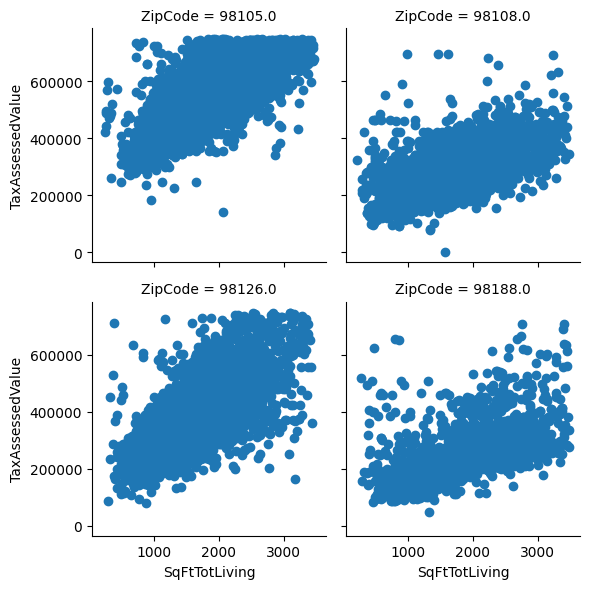

In [64]:
def scatter1(x,y,color,**kwargs):
    cmap = sns.light_palette(color,as_cmap=True)
    plt.scatter(x,y,  cmap=cmap, **kwargs)
    
g = sns.FacetGrid(kc_tax_zip, col="ZipCode", col_wrap=2)
g.map(scatter1, 'SqFtTotLiving', 'TaxAssessedValue')
plt.tight_layout()
plt.show()

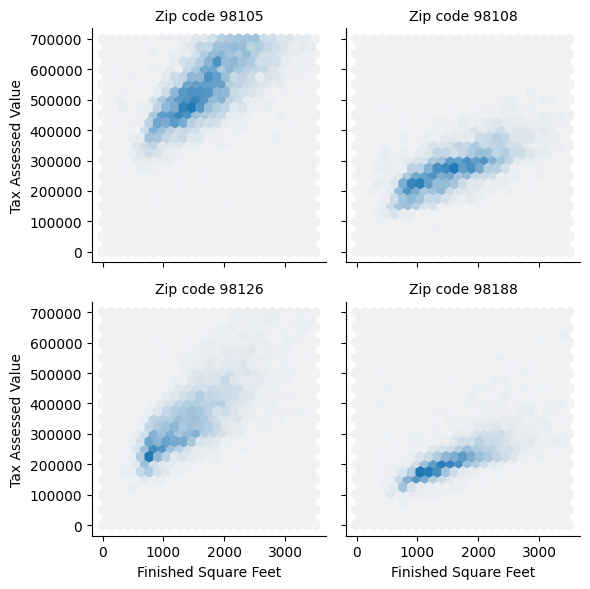

In [65]:
def hexbin1(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin1, 'SqFtTotLiving', 'TaxAssessedValue', 
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

plt.tight_layout()
plt.show()

In [72]:
loans = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/loans_income.csv").squeeze("columns")
loans

0         67000
1         52000
2        100000
3         78762
4         37041
          ...  
49995     40000
49996     54000
49997     50000
49998     82000
49999     70000
Name: x, Length: 50000, dtype: int64

In [75]:
sample_data = pd.DataFrame({"income": loans.sample(1000),
                            "type": "data"})

sample_mean_5 = pd.DataFrame({"income": [loans.sample(5).mean() for _ in range(1000)],
                            "type": "mean5"})

sample_mean_20 = pd.DataFrame({"income": [loans.sample(20).mean() for _ in range(1000)],
                            "type": "mean20"})

general_samples = pd.concat([sample_data, sample_mean_5, sample_mean_20])
general_samples

,income,type
30455,111000.00,data
29367,40000.00,data
29695,41000.00,data
8935,75000.00,data
47262,56000.00,data
...,...,...
995,69395.60,mean20
996,73014.80,mean20
997,62479.10,mean20
998,78580.15,mean20


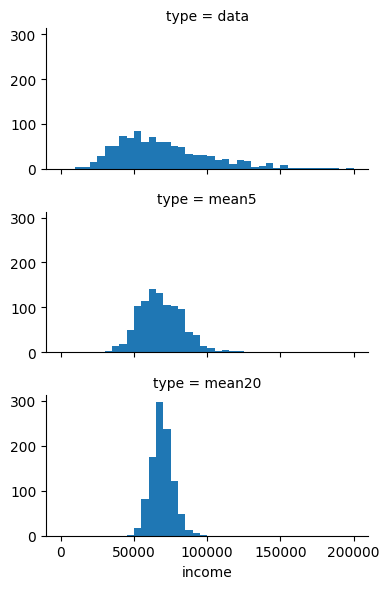

In [77]:
g = sns.FacetGrid(general_samples, col="type", col_wrap=1, height=2, aspect=2)
g.map(plt.hist, "income", range=[0,200_000], bins=40)

plt.tight_layout()
plt.show()